# Model 3: Fine-tuned Sentence Transformer (bi-encoder)

Bi-encoder: encode question1/question2 separately, compare via cosine similarity -- same shape as Model 0.2 (TF-IDF + cosine), but with a fine-tuned transformer instead of TF-IDF, so it captures semantic similarity rather than exact word overlap.

Chosen over CrossEncoder for scalability: embeddings can be precomputed once and compared via fast cosine similarity, which matches the real-world use case (checking a new question against a large bank of existing ones).

## Setup

In [1]:
%pip install sentence-transformers

In [2]:
import sys
sys.path.append('..')

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from sklearn.metrics.pairwise import paired_cosine_distances
from evaluation import train_and_evaluate, quick_log_loss
from sklearn.metrics import f1_score
from evaluation import compute_metrics, append_to_experiment_table, plot_confusion_matrix
from google.colab import files

pd.set_option('display.max_colwidth', None)

/tmp/ipykernel_473/1668178924.py:6: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


### Load data and reuse the same train/val split

Same `train_test_split(test_size=0.2, stratify=y, random_state=42)` as `02_baseline.ipynb`/`03_xgboost.ipynb`, so the val set is identical across all models.

In [4]:
raw_df = pd.read_csv('/content/quora_with_features.csv', index_col=0)

X = raw_df.drop(columns=['is_duplicate'])
y = raw_df['is_duplicate']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
raw_df.head(5)

,qid1,qid2,question1,question2,is_duplicate,question1_len,question2_len,len_dif,common_words,jaccard_similarity,word_match_share,bigrams_common,bigram_jaccard_similarity,bigram_word_match_share,cosine_similarity
id,,,,,,,,,,,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,47,81,-34,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,62,55,7,3.0,0.600000,0.375000,1.0,0.200000,0.166667,0.827243
113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,32,78,-46,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.149953
266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,51,42,9,2.0,0.250000,0.200000,1.0,0.142857,0.125000,0.345153
122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,159,68,91,4.0,0.235294,0.190476,1.0,0.055556,0.052632,0.233961


### Training on the full train set

Full `X_train` is 258,743 pairs. At ~0.105s/step (batch_size=16), a full epoch takes ~35 min -- cheap enough to train on the full set directly rather than subsampling. `EPOCHS = 2` (down from 3 used in the initial 20k sanity check), since the full set has far more unique pairs per epoch.

## Base model

`all-MiniLM-L6-v2` (384-dim, fast, strong general semantic-similarity performance).

In [6]:
ST_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
# Small stratified probe sample, just to measure step time (not for real training)
PROBE_SIZE = 500
BATCH_SIZE = 16

probe_df, _ = train_test_split(
    X_train.assign(is_duplicate=y_train),
    train_size=PROBE_SIZE,
    stratify=y_train,
    random_state=42,
)

probe_examples = [
    InputExample(texts=[row.question1, row.question2], label=float(row.is_duplicate))
    for row in probe_df.itertuples()
]
probe_loader = DataLoader(probe_examples, shuffle=True, batch_size=BATCH_SIZE)
probe_loss = losses.CosineSimilarityLoss(ST_model)

start = time.time()
ST_model.fit(
    train_objectives=[(probe_loader, probe_loss)],
    epochs=1,
    show_progress_bar=False,
)
elapsed = time.time() - start

n_steps = len(probe_loader)
sec_per_step = elapsed / n_steps
print(f'{elapsed:.1f}s for {n_steps} steps -> {sec_per_step:.3f}s/step at batch_size={BATCH_SIZE}')

# Extrapolate: for a candidate N_SAMPLE and EPOCHS, estimate total training time
for N_SAMPLE in [5_000, 10_000, 20_000, 50_000]:
    for EPOCHS in [1, 2, 3]:
        est_steps = (N_SAMPLE / BATCH_SIZE) * EPOCHS
        est_minutes = est_steps * sec_per_step / 60
        print(f'N_SAMPLE={N_SAMPLE:>6} epochs={EPOCHS} -> ~{est_minutes:.1f} min')

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

{'train_runtime': '4.59', 'train_samples_per_second': '108.9', 'train_steps_per_second': '6.971', 'train_loss': '0.2343', 'epoch': '1'}
5.6s for 32 steps -> 0.174s/step at batch_size=16
N_SAMPLE=  5000 epochs=1 -> ~0.9 min
N_SAMPLE=  5000 epochs=2 -> ~1.8 min
N_SAMPLE=  5000 epochs=3 -> ~2.7 min
N_SAMPLE= 10000 epochs=1 -> ~1.8 min
N_SAMPLE= 10000 epochs=2 -> ~3.6 min
N_SAMPLE= 10000 epochs=3 -> ~5.5 min
N_SAMPLE= 20000 epochs=1 -> ~3.6 min
N_SAMPLE= 20000 epochs=2 -> ~7.3 min
N_SAMPLE= 20000 epochs=3 -> ~10.9 min
N_SAMPLE= 50000 epochs=1 -> ~9.1 min
N_SAMPLE= 50000 epochs=2 -> ~18.2 min
N_SAMPLE= 50000 epochs=3 -> ~27.3 min


In [8]:
#reloading model
ST_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Full train set, combined into one DataFrame (`question1`/`question2`/`is_duplicate`) for the `InputExample` step below.

In [9]:
EPOCHS = 2

train_full_df = X_train.assign(is_duplicate=y_train)

## Prepare training examples

`InputExample(texts=[q1, q2], label=is_duplicate)` pairs, built from the full train set. `label` (0/1) doubles as the target cosine similarity for the loss below.

In [10]:
train_examples = [
    InputExample(texts=[row.question1, row.question2], label=float(row.is_duplicate))
    for row in train_full_df.itertuples()
]

## Fine-tune

`CosineSimilarityLoss` pushes cosine similarity of the two embeddings toward the 0/1 label.

In [11]:
train_loader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)
train_loss = losses.CosineSimilarityLoss(ST_model)

warmup_steps = len(train_loader) * EPOCHS * 0.1
start = time.time()
ST_model.fit(
    train_objectives=[(train_loader, train_loss)],
    epochs=EPOCHS,
    warmup_steps=warmup_steps,
    show_progress_bar=False
)
elapsed = time.time() - start

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

{'loss': '0.2169', 'grad_norm': '1.122', 'learning_rate': '3.086e-06', 'epoch': '0.03092'}
{'loss': '0.1707', 'grad_norm': '1.838', 'learning_rate': '6.177e-06', 'epoch': '0.06184'}
{'loss': '0.1464', 'grad_norm': '1.391', 'learning_rate': '9.269e-06', 'epoch': '0.09275'}
{'loss': '0.1424', 'grad_norm': '1.933', 'learning_rate': '1.236e-05', 'epoch': '0.1237'}
{'loss': '0.139', 'grad_norm': '2.406', 'learning_rate': '1.545e-05', 'epoch': '0.1546'}
{'loss': '0.1391', 'grad_norm': '1.913', 'learning_rate': '1.854e-05', 'epoch': '0.1855'}
{'loss': '0.136', 'grad_norm': '1.768', 'learning_rate': '1.982e-05', 'epoch': '0.2164'}
{'loss': '0.131', 'grad_norm': '2.016', 'learning_rate': '1.947e-05', 'epoch': '0.2473'}
{'loss': '0.128', 'grad_norm': '2.019', 'learning_rate': '1.913e-05', 'epoch': '0.2783'}
{'loss': '0.1284', 'grad_norm': '2.493', 'learning_rate': '1.879e-05', 'epoch': '0.3092'}
{'loss': '0.1241', 'grad_norm': '1.998', 'learning_rate': '1.844e-05', 'epoch': '0.3401'}
{'loss': '0

## Evaluate on the val split

Encode `question1`/`question2` from `X_val`, compute pairwise cosine similarity (same computation as `cosine_similarity` in `src/features.py`, using these embeddings instead of TF-IDF vectors), then threshold and score with `compute_metrics`/`append_to_experiment_table` -- same functions used by every other model, so results land in `reports/experiment_table.csv` in the same format.

In [12]:
q1_embeddings_val = ST_model.encode(X_val['question1'].tolist(), show_progress_bar=True)
q2_embeddings_val = ST_model.encode(X_val['question2'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/2022 [00:00<?, ?it/s]

Batches:   0%|          | 0/2022 [00:00<?, ?it/s]

In [13]:
similarity_val = (1 - paired_cosine_distances(q1_embeddings_val, q2_embeddings_val)).clip(0, 1)

In [14]:
q1_embeddings_train = ST_model.encode(train_full_df['question1'].tolist(), show_progress_bar=True)
q2_embeddings_train = ST_model.encode(train_full_df['question2'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/8086 [00:00<?, ?it/s]

Batches:   0%|          | 0/8086 [00:00<?, ?it/s]

In [15]:
similarity_train = (1 - paired_cosine_distances(q1_embeddings_train, q2_embeddings_train)).clip(0, 1)

In [16]:
#chosing of threshold

best_f1, best_threshold = 0, 0
for threshold in np.arange(0.1, 0.9, 0.05):
    y_pred_temp = (similarity_train > threshold).astype(int)
    f1 = f1_score(train_full_df['is_duplicate'], y_pred_temp)
    if f1 > best_f1:
        best_f1, best_threshold = f1, threshold

#prediction on val
y_pred = (similarity_val > best_threshold).astype(int)

In [17]:
y_pred_train = (similarity_train > best_threshold).astype(int)
y_train_full = train_full_df['is_duplicate']

train_score = {
    'f1': f1_score(y_train_full, y_pred_train),
    'roc_auc': roc_auc_score(y_train_full, similarity_train),
    'log_loss': log_loss(y_train_full, similarity_train),
}

results_model_3 = compute_metrics(y_val, y_pred, similarity_val, 'Model 3 - Sentence Transformer (bi-encoder)', threshold=best_threshold, train_score=train_score)

model: Model 3 - Sentence Transformer (bi-encoder)

threshold: 0.6000000000000002

params: None

train_time_sec: None

train_f1: 0.8655789521672399

train_roc_auc: 0.9576900085700748

train_log_loss: 0.2920401274532791

f1: 0.8250513843549752

roc_auc: 0.9359661278119693

log_loss: 0.3482835890364064



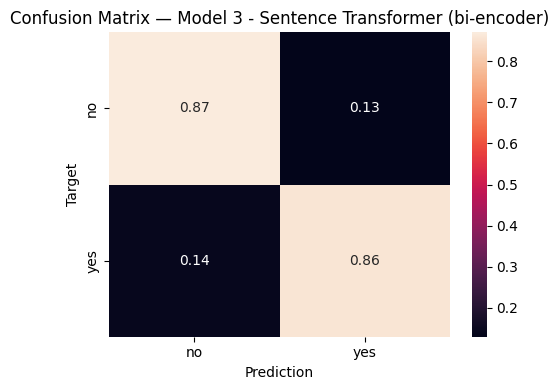

In [18]:
plot_confusion_matrix(y_val, y_pred, 'Model 3 - Sentence Transformer (bi-encoder)')


In [19]:
append_to_experiment_table(results_model_3, path='/content/experiment_table.csv')

## Save

`ST_model.save(...)` persists the fine-tuned model to `models/sentence_transformer_duplicate_model/` (used later in `06_error_analysis.ipynb`, `07_test_evaluation.ipynb`, and the Streamlit app).

In [20]:
ST_model.save('sentence_transformer_duplicate_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
!zip -r sentence_transformer_duplicate_model.zip sentence_transformer_duplicate_model

files.download('sentence_transformer_duplicate_model.zip')

  adding: sentence_transformer_duplicate_model/ (stored 0%)
  adding: sentence_transformer_duplicate_model/sentence_bert_config.json (deflated 43%)
  adding: sentence_transformer_duplicate_model/1_Pooling/ (stored 0%)
  adding: sentence_transformer_duplicate_model/1_Pooling/config.json (deflated 16%)
  adding: sentence_transformer_duplicate_model/config.json (deflated 52%)
  adding: sentence_transformer_duplicate_model/tokenizer_config.json (deflated 51%)
  adding: sentence_transformer_duplicate_model/2_Normalize/ (stored 0%)
  adding: sentence_transformer_duplicate_model/model.safetensors (deflated 8%)
  adding: sentence_transformer_duplicate_model/README.md (deflated 65%)
  adding: sentence_transformer_duplicate_model/modules.json (deflated 64%)
  adding: sentence_transformer_duplicate_model/config_sentence_transformers.json (deflated 40%)
  adding: sentence_transformer_duplicate_model/tokenizer.json (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>